In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset 1 

In [2]:
data_raw= pd.read_csv(r"C:\Users\zakar\Desktop\School\Y2\BLOCK A\Week9-10\Datasets\Dataset_lichess_kaggle\games.csv")
data_raw.describe

<bound method NDFrame.describe of              id  rated    created_at  last_move_at  turns victory_status  \
0      TZJHLljE  False  1.504210e+12  1.504210e+12     13      outoftime   
1      l1NXvwaE   True  1.504130e+12  1.504130e+12     16         resign   
2      mIICvQHh   True  1.504130e+12  1.504130e+12     61           mate   
3      kWKvrqYL   True  1.504110e+12  1.504110e+12     61           mate   
4      9tXo1AUZ   True  1.504030e+12  1.504030e+12     95           mate   
...         ...    ...           ...           ...    ...            ...   
20053  EfqH7VVH   True  1.499791e+12  1.499791e+12     24         resign   
20054  WSJDhbPl   True  1.499698e+12  1.499699e+12     82           mate   
20055  yrAas0Kj   True  1.499698e+12  1.499698e+12     35           mate   
20056  b0v4tRyF   True  1.499696e+12  1.499697e+12    109         resign   
20057  N8G2JHGG   True  1.499643e+12  1.499644e+12     78           mate   

      winner increment_code       white_id  white_rat

In [3]:
data_raw.columns

Index(['id', 'rated', 'created_at', 'last_move_at', 'turns', 'victory_status',
       'winner', 'increment_code', 'white_id', 'white_rating', 'black_id',
       'black_rating', 'moves', 'opening_eco', 'opening_name', 'opening_ply'],
      dtype='object')

In [4]:
data_raw.dtypes

id                 object
rated                bool
created_at        float64
last_move_at      float64
turns               int64
victory_status     object
winner             object
increment_code     object
white_id           object
white_rating        int64
black_id           object
black_rating        int64
moves              object
opening_eco        object
opening_name       object
opening_ply         int64
dtype: object

In [5]:
data_raw['created_at'].head()

0    1.504210e+12
1    1.504130e+12
2    1.504130e+12
3    1.504110e+12
4    1.504030e+12
Name: created_at, dtype: float64

In [6]:
df = data_raw
# changing the columns from datetime64[ns] datatype to readable date data 
df['created_at'] = pd.to_datetime(df['created_at'], unit='ms')
df['last_move_at'] = pd.to_datetime(df['last_move_at'], unit='ms')


In [7]:
def format_chess_moves(moves):
    moves_list = moves.split()
    formatted_moves = ""
    
    for i in range(0, len(moves_list), 2):
        move_number = i // 2 + 1
        if i + 1 < len(moves_list):
            formatted_moves += f"{move_number}. {moves_list[i]} {moves_list[i + 1]} "
        else:
            formatted_moves += f"{move_number}. {moves_list[i]}"
    
    return formatted_moves.strip()

# Apply the function to the 'moves' column
df['moves'] = df['moves'].apply(format_chess_moves)


In [8]:
df['created_at'].head()

0   2017-08-31 20:06:40
1   2017-08-30 21:53:20
2   2017-08-30 21:53:20
3   2017-08-30 16:20:00
4   2017-08-29 18:06:40
Name: created_at, dtype: datetime64[ns]

In [9]:
df.duplicated().sum()

429

In [10]:
df = df.drop_duplicates()
df.duplicated().sum()

0

In [11]:
df.isna().sum()

id                0
rated             0
created_at        0
last_move_at      0
turns             0
victory_status    0
winner            0
increment_code    0
white_id          0
white_rating      0
black_id          0
black_rating      0
moves             0
opening_eco       0
opening_name      0
opening_ply       0
dtype: int64

In [11]:
df.to_csv('CLEANED_games.csv', index=False)

## EDA

### Average ratings between white and black

C:\Users\zakar\AppData\Local\Temp\ipykernel_14320\2513179257.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Ratings')


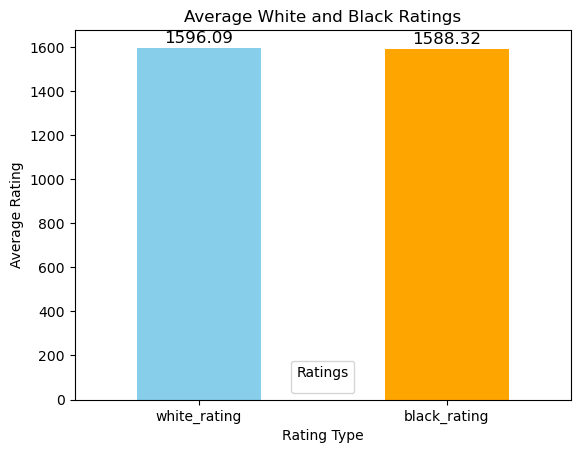

In [27]:
avg_ratings = df[['white_rating', 'black_rating']].mean()

# Plotting the averages as a bar chart

ax = avg_ratings.plot(kind='bar', color=['skyblue', 'orange'])


for i, v in enumerate(avg_ratings):
    ax.text(i, v + 10, round(v, 2), ha='center', va='bottom', fontsize=12)

plt.title('Average White and Black Ratings')
plt.xlabel('Rating Type')
plt.ylabel('Average Rating')
plt.xticks(rotation=0)  
plt.legend(title='Ratings')
plt.show()


Average of ratings is almost equal so there is no imbalance between players ELO's generally speaking.

### Frequency of victory status

In [28]:
df['victory_status'].unique()

array(['outoftime', 'resign', 'mate', 'draw'], dtype=object)

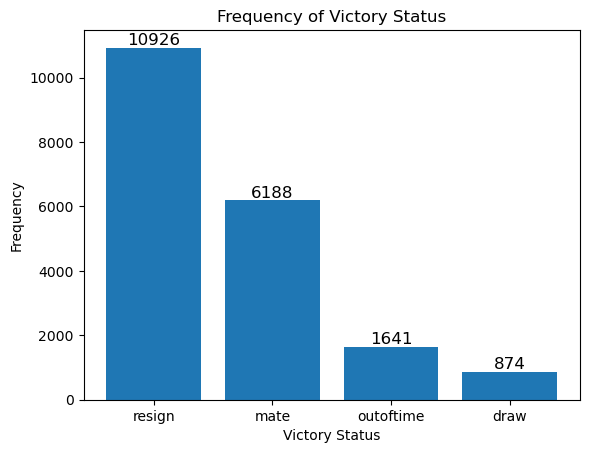

In [ ]:
freq = df['victory_status'].value_counts()

plt.bar(freq.index, freq.values)
for i, v in enumerate(freq.values):
    plt.text(i, v + 0.1, str(v), ha='center', va='bottom', fontsize=12)


plt.title('Frequency of Victory Status')
plt.xlabel('Victory Status')
plt.ylabel('Frequency')

# Showing the plot
plt.show()

                white_rating  black_rating
victory_status                            
draw             1652.676201   1639.710526
mate             1529.420976   1522.748707
outoftime        1611.190737   1607.466179
resign           1627.054274   1618.478492


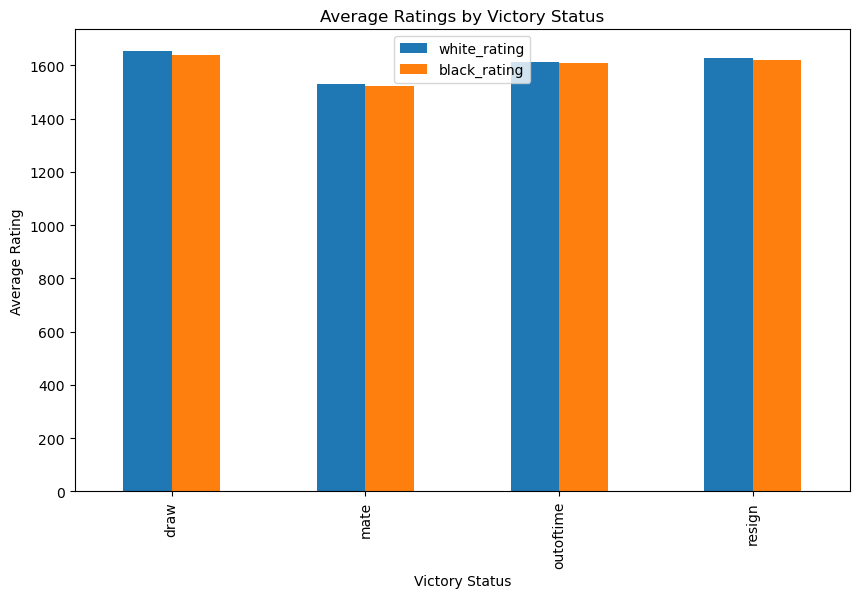

In [30]:
# Calculating the average rating for each victory status
average_ratings = df.groupby('victory_status')[['white_rating', 'black_rating']].mean()
print(average_ratings)

# Plotting the average ratings
average_ratings.plot(kind='bar', figsize=(10, 6))
plt.xlabel("Victory Status")
plt.ylabel("Average Rating")
plt.title("Average Ratings by Victory Status")
plt.show()


C:\Users\zakar\AppData\Local\Temp\ipykernel_14320\88051049.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=opening_counts.values, y=opening_counts.index, palette="viridis")


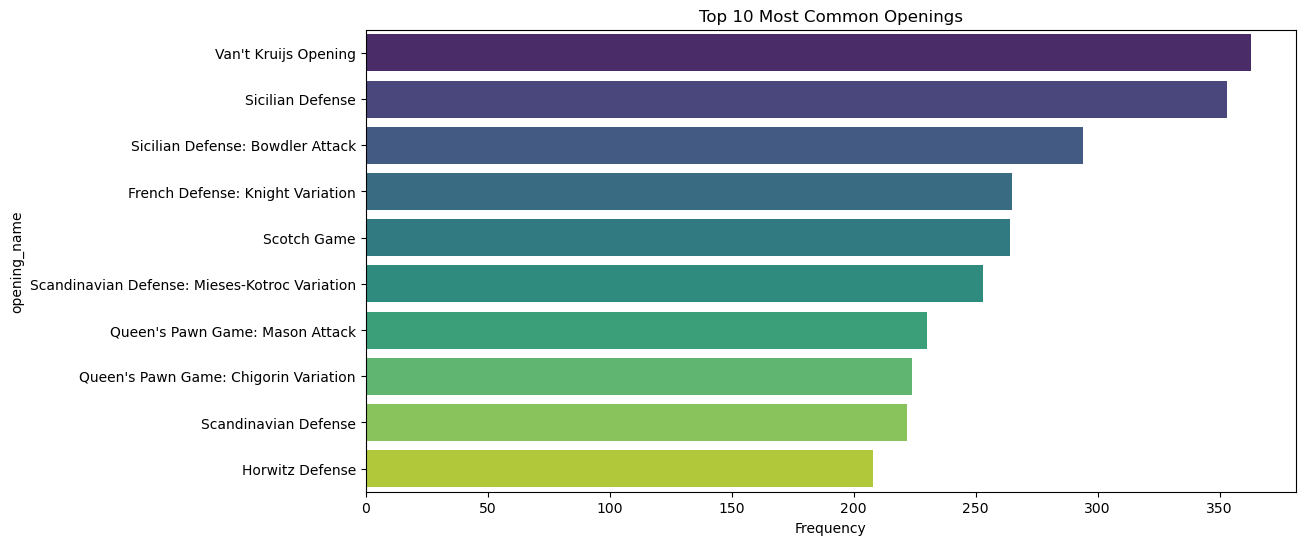

In [31]:
# Top 10 most common openings
opening_counts = df['opening_name'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=opening_counts.values, y=opening_counts.index, palette="viridis")
plt.title("Top 10 Most Common Openings")
plt.xlabel("Frequency")
plt.show()


C:\Users\zakar\AppData\Local\Temp\ipykernel_14320\384905572.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['white_level'] = df['white_rating'].apply(categorize_level)
C:\Users\zakar\AppData\Local\Temp\ipykernel_14320\384905572.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['black_level'] = df['black_rating'].apply(categorize_level)


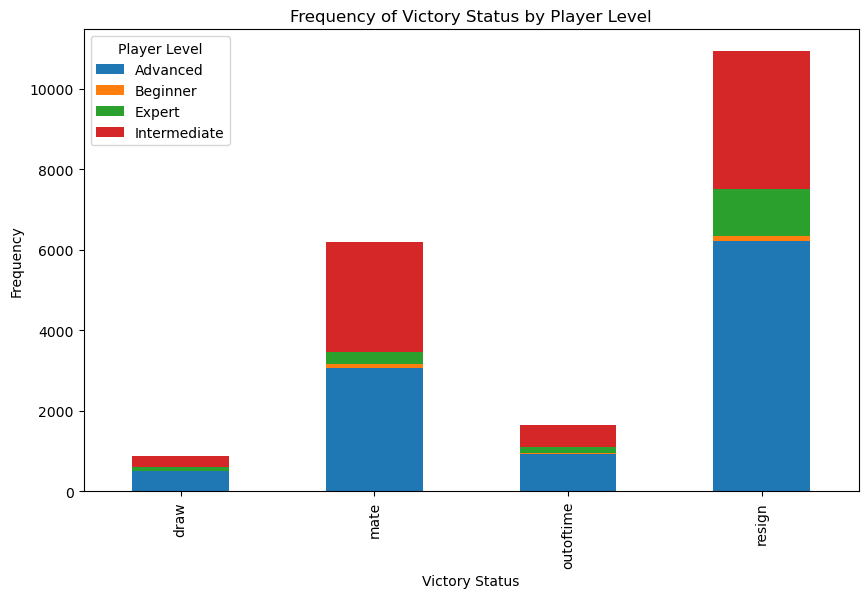

In [ ]:
import pandas as pd

# Defining rating categories
def categorize_level(rating):
    if rating < 1000:
        return 'Beginner'
    elif rating < 1500:
        return 'Intermediate'
    elif rating < 2000:
        return 'Advanced'
    else:
        return 'Expert'

# Applying to both players' ratings
df['white_level'] = df['white_rating'].apply(categorize_level)
df['black_level'] = df['black_rating'].apply(categorize_level)

victory_by_level = df.groupby(['victory_status', 'white_level']).size().unstack(fill_value=0)
import matplotlib.pyplot as plt

# Plotting a bar chart for each level
victory_by_level.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Frequency of Victory Status by Player Level')
plt.xlabel('Victory Status')
plt.ylabel('Frequency')
plt.legend(title='Player Level')
plt.show()


# Random Testing

In [ ]:
import pandas as pd

# Defining rating categories
def categorize_player_level(rating):
    if rating < 1000:
        return 'Beginner'
    elif rating < 1500:
        return 'Intermediate'
    elif rating < 2000:
        return 'Advanced'
    else:
        return 'Expert'

# Applying to both players' ratings
df['white_level'] = df['white_rating'].apply(categorize_level)
df['black_level'] = df['black_rating'].apply(categorize_level)


C:\Users\zakar\AppData\Local\Temp\ipykernel_14320\681167023.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['white_level'] = df['white_rating'].apply(categorize_level)
C:\Users\zakar\AppData\Local\Temp\ipykernel_14320\681167023.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['black_level'] = df['black_rating'].apply(categorize_level)


In [ ]:
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# Assuming df is the cleaned DataFrame
df['player_level'] = df['white_rating'].apply(lambda x: categorize_player_level(x))

# Convertting moves to a sequence of numbers
# Creating a function to map each move to a unique integer
move_dict = {move: idx for idx, move in enumerate(set(" ".join(df['moves']).split()))}
df['move_sequence'] = df['moves'].apply(lambda x: [move_dict[move] for move in x.split()])

# Padding sequences to ensure equal length input for LSTM
max_sequence_length = 50  
X_moves = pad_sequences(df['move_sequence'], maxlen=max_sequence_length, padding='post')

# Encoding target labels
y = to_categorical(df['victory_status'].factorize()[0])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_moves, y, test_size=0.2, random_state=42)


C:\Users\zakar\AppData\Local\Temp\ipykernel_14320\921410138.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['player_level'] = df['white_rating'].apply(lambda x: categorize_player_level(x))
C:\Users\zakar\AppData\Local\Temp\ipykernel_14320\921410138.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['move_sequence'] = df['moves'].apply(lambda x: [move_dict[move] for move in x.split()])


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding, Dropout

# Defining the LSTM model
model = Sequential([
    Embedding(input_dim=len(move_dict) + 1, output_dim=64, input_length=max_sequence_length),
    LSTM(128, return_sequences=True),
    Dropout(0.2),
    LSTM(64),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(y.shape[1], activation='softmax')
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


c:\Users\zakar\anaconda3\envs\Chess\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Training the model
history = model.fit(X_train, y_train, epochs=10, batch_size=64, validation_data=(X_test, y_test))


In [ ]:
# Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy}")

# Save the model for later use
model.save('chess_coach_model.h5')


123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8433 - loss: 0.5809


Test Accuracy: 0.8374936580657959


In [ ]:
# Sampling move sequence (This is useful after if i choose to encode the sequences in integers)
# Example sequence
sample_game_moves = [3, 18, 25, 7, 42, 12, 32, 5, 19, 22]  

# Padding the sequence to the model’s expected input length 
max_sequence_length = 50  
test_input = pad_sequences([sample_game_moves], maxlen=max_sequence_length, padding='pre')

# Reshape the input if necessary (e.g., for an LSTM expecting 3D input)
test_input = np.reshape(test_input, (1, max_sequence_length)) 


In [ ]:
predicted_output = model.predict(test_input)

#  the output
print("Predicted Victory Status Probabilities:", predicted_output)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step
Predicted Victory Status Probabilities: [[0.24362668 0.6264212  0.00186994 0.12808225]]


In [ ]:

# Providing the path to the downloaded Stockfish executable
stockfish = Stockfish(path=r"C:\Users\zakar\Desktop\School\Y2\BLOCK A\Week9-10\stockfish-windows-x86-64-avx2\stockfish\stockfish-windows-x86-64-avx2.exe")  
# I chose the highest level 20 just to test
stockfish.set_skill_level(20)  


In [ ]:
def recommend_move(fen_position, depth=15):
    """
    Uses Stockfish to recommend the best move for a given board position.
    
    Parameters:
    - fen_position (str): The FEN string of the board position.
    - depth (int): The depth for Stockfish to search moves; higher values provide better recommendations but take longer.
    
    Returns:
    - str: The best move in standard chess notation (e.g., "e2e4").
    """
    stockfish.set_fen_position(fen_position)
    stockfish.set_depth(depth)
    best_move = stockfish.get_best_move()
    return best_move


In [ ]:
# Starting position in FEN
start_position = "rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1"

# Getting the best move for the starting position
best_move = recommend_move(start_position)
print("Recommended move:", best_move)


Recommended move: e2e4


In [ ]:
midgame_position = "r1bqkbnr/pppppppp/2n5/8/1b6/5N2/PPPPPPPP/RNBQKB1R w KQkq - 2 3"

best_move = recommend_move(midgame_position)
print("Recommended move for midgame position:", best_move)


Recommended move for midgame position: e2e3


In [ ]:
def recommend_multiple_moves(fen_position, num_moves=3, depth=15):
    """
    Get the top recommended moves and evaluations for a given position.
    
    Parameters:
    - fen_position (str): The FEN string of the board position.
    - num_moves (int): The number of top moves to return.
    - depth (int): The depth for Stockfish to analyze moves.
    
    Returns:
    - list of tuples: Each tuple contains (move, evaluation) for the best moves.
    """
    stockfish.set_fen_position(fen_position)
    stockfish.set_depth(depth)
    
    top_moves = stockfish.get_top_moves(num_moves)
    return [(move['Move'], move['Centipawn']) for move in top_moves]


In [ ]:
top_moves = recommend_multiple_moves(start_position, num_moves=3)
print("Top 3 recommended moves:", top_moves)


Top 3 recommended moves: [('e2e4', 26), ('d2d4', 23), ('g1f3', 19)]


# Dataset 2 

In [70]:
df2 = pd.read_csv(r"C:\Users\zakar\Desktop\School\Y2\BLOCK A\Week9-10\Datasets\Dataset_chesscom_kaggle_60k\club_games_data.csv")

df2.head()

,white_username,black_username,white_id,black_id,white_rating,black_rating,white_result,black_result,time_class,time_control,rules,rated,fen,pgn
0,-Amos-,miniman2804,https://api.chess.com/pub/player/-amos-,https://api.chess.com/pub/player/miniman2804,1708,1608,win,checkmated,daily,1/259200,chess,True,r2r4/p2p1p1p/b6R/n1p1kp2/2P2P2/3BP3/PP5P/4K2R ...,"[Event ""Enjoyable games 2 - Round 1""]\n[Site ""..."
1,-Amos-,koltcho69,https://api.chess.com/pub/player/-amos-,https://api.chess.com/pub/player/koltcho69,1726,1577,win,resigned,daily,1/172800,chess,True,8/5Q1k/4n1pp/8/7P/2N2b2/PP3P2/5K2 b - - 1 33,"[Event ""Rapid Rats - Board 5""]\n[Site ""Chess.c..."
2,-Amos-,enhmandah,https://api.chess.com/pub/player/-amos-,https://api.chess.com/pub/player/enhmandah,1727,842,win,resigned,daily,1/172800,chess,True,rn1q1b1r/kb2p1pp/2p5/p1Q5/N1BP2n1/4PN2/1P3PPP/...,"[Event ""CHESS BOARD CLASH - Round 1""]\n[Site ""..."
3,enhmandah,-Amos-,https://api.chess.com/pub/player/enhmandah,https://api.chess.com/pub/player/-amos-,819,1727,checkmated,win,daily,1/172800,chess,True,r3kb1r/pp3ppp/3p1n2/2pKp3/P3P3/1P6/4qP1P/QNB5 ...,"[Event ""CHESS BOARD CLASH - Round 1""]\n[Site ""..."
4,-Amos-,Shalllow-Blue,https://api.chess.com/pub/player/-amos-,https://api.chess.com/pub/player/shalllow-blue,1729,1116,win,resigned,daily,1/172800,chess,True,r3b2r/pp6/2pPpR1k/4n3/2P3Q1/3B4/PP4PP/R5K1 b -...,"[Event ""CHESS BOARD CLASH - Round 1""]\n[Site ""..."


In [71]:
df2.head

<bound method NDFrame.head of       white_username black_username  \
0             -Amos-    miniman2804   
1             -Amos-      koltcho69   
2             -Amos-      enhmandah   
3          enhmandah         -Amos-   
4             -Amos-  Shalllow-Blue   
...              ...            ...   
66874      Alyushkov  abdullahnasib   
66875  abdullahnasib   Nizaamulmulk   
66876         esadot  abdullahnasib   
66877  abdullahnasib  FrancescoPops   
66878      IlkayGott  abdullahnasib   

                                             white_id  \
0             https://api.chess.com/pub/player/-amos-   
1             https://api.chess.com/pub/player/-amos-   
2             https://api.chess.com/pub/player/-amos-   
3          https://api.chess.com/pub/player/enhmandah   
4             https://api.chess.com/pub/player/-amos-   
...                                               ...   
66874      https://api.chess.com/pub/player/alyushkov   
66875  https://api.chess.com/pub/player/abdul

In [72]:
df2.dtypes

white_username    object
black_username    object
white_id          object
black_id          object
white_rating       int64
black_rating       int64
white_result      object
black_result      object
time_class        object
time_control      object
rules             object
rated               bool
fen               object
pgn               object
dtype: object

In [73]:
df2.isna().sum()

white_username    0
black_username    0
white_id          0
black_id          0
white_rating      0
black_rating      0
white_result      0
black_result      0
time_class        0
time_control      0
rules             0
rated             0
fen               0
pgn               0
dtype: int64

In [74]:
df2.duplicated().sum()

4

In [75]:
df2 = df2.drop_duplicates()
df2.duplicated().sum()

0

In [ ]:

df2[['days', 'hours', 'minutes', 'seconds']] = df2['time_control'].str.extract(r'(\d+)/(\d+)/(\d+)/(\d+)').fillna(0).astype(int)
df2.drop(columns=['time_control'], inplace=True)

#  Standardizing player result terms (e.g., "checkmated" and "resigned" to more common win/loss labels) (FOR TESTING PURPOSES, CHANGE THEM BACK LATER )
df2['white_result'] = df2['white_result'].replace({'checkmated': 'loss', 'resigned': 'loss'}).replace('win', 'win')
df2['black_result'] = df2['black_result'].replace({'checkmated': 'loss', 'resigned': 'loss'}).replace('win', 'win')

C:\Users\zakar\AppData\Local\Temp\ipykernel_14320\27879844.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df2[['days', 'hours', 'minutes', 'seconds']] = df2['time_control'].str.extract(r'(\d+)/(\d+)/(\d+)/(\d+)').fillna(0).astype(int)
C:\Users\zakar\AppData\Local\Temp\ipykernel_14320\27879844.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2[['days', 'hours', 'minutes', 'seconds']] = df2['time_control'].str.extract(r'(\d+)/(\d+)/(\d+)/(\d+)').fillna(0).astype(int)
C:\Users\zakar\AppData\Local\Temp\ipykernel_14320\278798

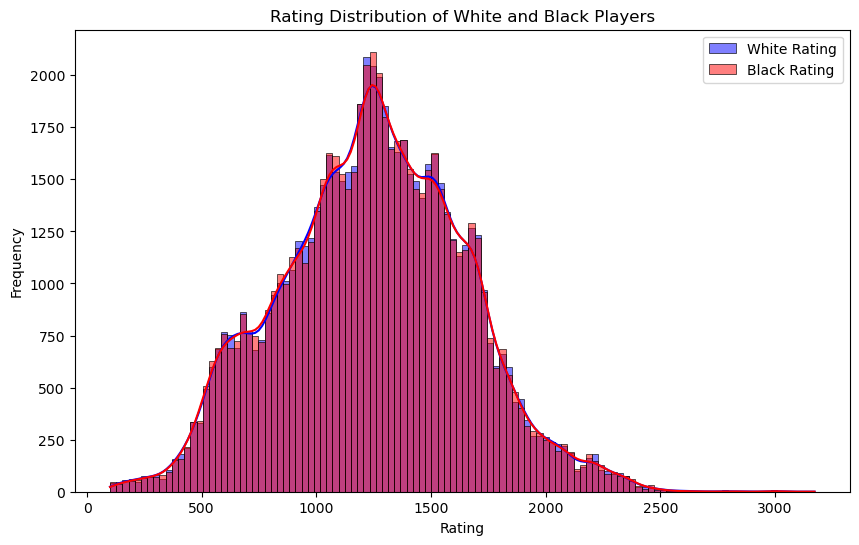

In [ ]:
# Rating Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df2['white_rating'], color="blue", label="White Rating", kde=True)
sns.histplot(df2['black_rating'], color="red", label="Black Rating", kde=True)
plt.legend()
plt.title("Rating Distribution of White and Black Players")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

C:\Users\zakar\AppData\Local\Temp\ipykernel_14320\949865988.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df2, x="white_result", order=["win", "loss"], palette="pastel")


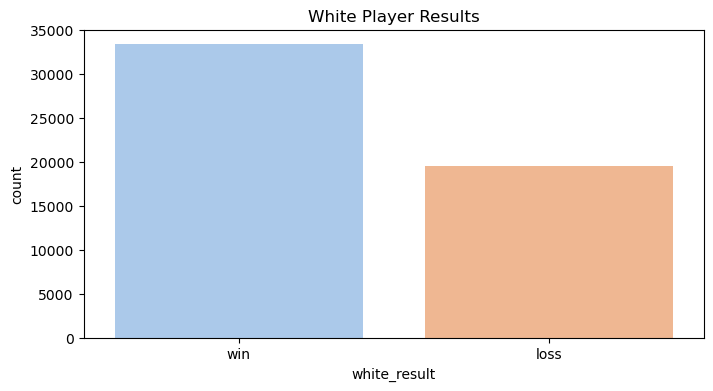

In [ ]:
# Win/Loss Counts by White 
plt.figure(figsize=(8, 4))
sns.countplot(data=df2, x="white_result", order=["win", "loss"], palette="pastel")
plt.title("White Player Results")
plt.show()

C:\Users\zakar\AppData\Local\Temp\ipykernel_14320\3479080202.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df2, x="black_result", order=["win", "loss"], palette="muted")


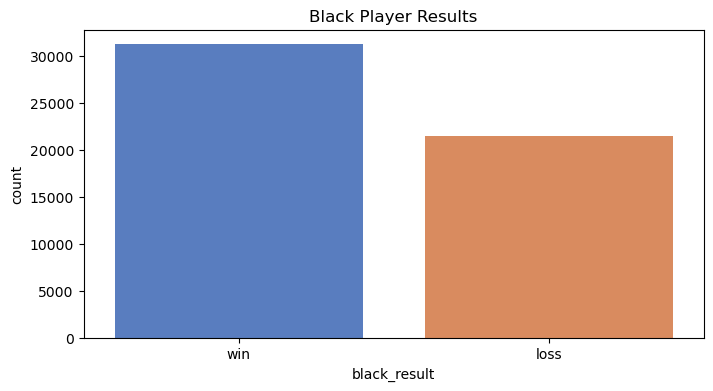

In [ ]:
# Win/Loss Counts by Black 
plt.figure(figsize=(8, 4))
sns.countplot(data=df2, x="black_result", order=["win", "loss"], palette="muted")
plt.title("Black Player Results")
plt.show()

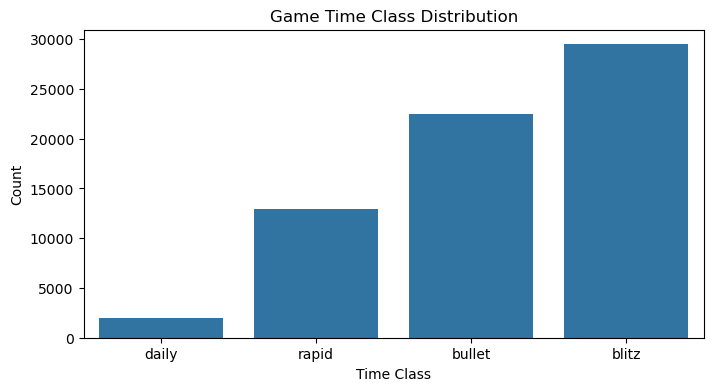

In [ ]:
# Distribution of Time Classes
plt.figure(figsize=(8, 4))
sns.countplot(data=df2, x="time_class")
plt.title("Game Time Class Distribution")
plt.xlabel("Time Class")
plt.ylabel("Count")
plt.show()


C:\Users\zakar\AppData\Local\Temp\ipykernel_14320\520079289.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['rating_difference'] = df2['white_rating'] - df2['black_rating']
C:\Users\zakar\AppData\Local\Temp\ipykernel_14320\520079289.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df2, x="white_result", y="rating_difference", palette="coolwarm")


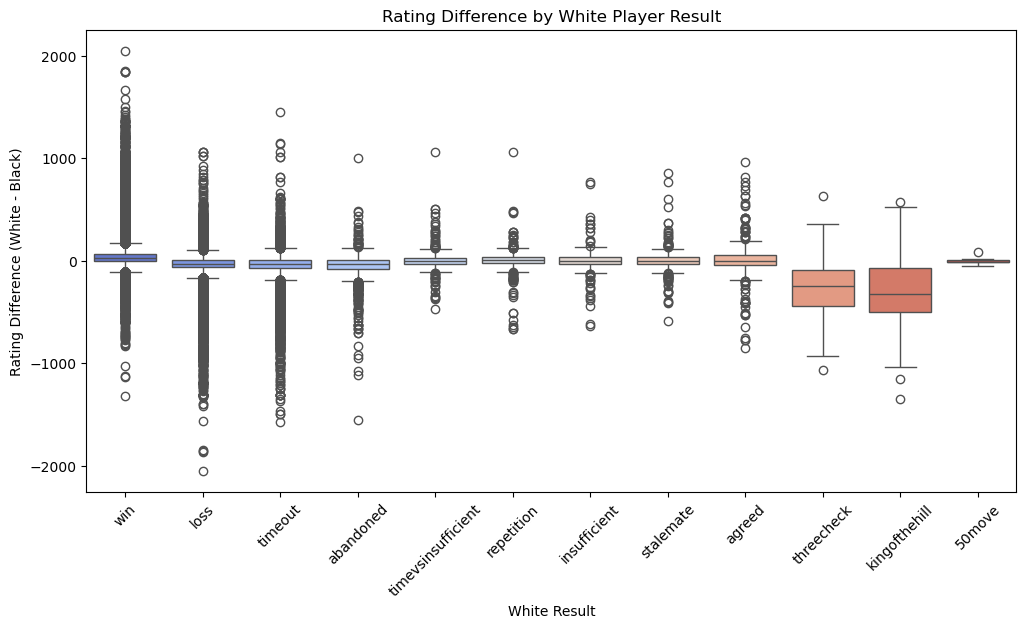

In [ ]:
# Rating Differences and Result Correlation
df2['rating_difference'] = df2['white_rating'] - df2['black_rating']
plt.figure(figsize=(12, 6))
sns.boxplot(data=df2, x="white_result", y="rating_difference", palette="coolwarm")
plt.title("Rating Difference by White Player Result")
plt.xlabel("White Result")
plt.xticks(rotation=45)
plt.ylabel("Rating Difference (White - Black)")
plt.show()